In [4]:
import pandas as pd
import numpy as np

# Direct link to the raw GitHub dataset (International Warfarin Pharmacogenetics Consortium)
iwpc_url = "https://raw.githubusercontent.com/ankmathur96/warfarin-bandits/master/data/warfarin.csv"

# Load the dataset directly into a DataFrame
df_real = pd.read_csv(iwpc_url)

print(f"Loaded {df_real.shape[0]} real patient records.")
cols_of_interest = [
    'Age', 'Weight (kg)', 'Height (cm)', 'Target INR', 
    'Cyp2C9 genotypes', 'VKORC1 -1639 consensus', 'Therapeutic Dose of Warfarin'
]
df_real[cols_of_interest].head()

Loaded 5701 real patient records.


,Age,Weight (kg),Height (cm),Target INR,Cyp2C9 genotypes,VKORC1 -1639 consensus,Therapeutic Dose of Warfarin
0,60 - 69,115.7,193.04,2.5,*1/*1,A/G,49.0
1,50 - 59,144.2,176.53,2.5,*1/*1,A/A,42.0
2,40 - 49,77.1,162.56,2.5,*1/*1,G/G,53.0
3,60 - 69,90.7,182.24,2.5,*1/*1,A/G,28.0
4,50 - 59,72.6,167.64,2.5,*1/*3,A/G,42.0


### Data Cleaning and Preprocessing
The IWPC dataset needs to be cleaned up as real-world datasets have missing values, and the column names need to match what we expect in our final XGBoost model (similar to the ones formulated in `WarfarinFinalModel.R`).

In [32]:
rename_map = {
    'Weight (kg)': 'Weight',
    'Height (cm)': 'Height',
    'Cyp2C9 genotypes': 'CYP2C9',
    'VKORC1 -1639 consensus': 'VKORC1',
    'Therapeutic Dose of Warfarin': 'WarfarinDose'
}

df_clean = df_real.rename(columns=rename_map).copy()

key_columns = [
    'Age', 'Weight', 'Height', 'Gender', 'CYP2C9', 'VKORC1', 
    'Amiodarone (Teronac)', 'Target INR', 'WarfarinDose'
]

existing_keys = [col for col in key_columns if col in df_clean.columns]
df_clean = df_clean[existing_keys].copy()

if 'WarfarinDose' in df_clean.columns:
    df_clean = df_clean.dropna(subset=['WarfarinDose'])

for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()

Clean dataset shape: (5528, 8)


,Age,Weight,Height,Gender,CYP2C9,VKORC1,Target INR,WarfarinDose
0,60 - 69,115.7,193.04,male,*1/*1,A/G,2.5,49.0
1,50 - 59,144.2,176.53,female,*1/*1,A/A,2.5,42.0
2,40 - 49,77.1,162.56,female,*1/*1,G/G,2.5,53.0
3,60 - 69,90.7,182.24,male,*1/*1,A/G,2.5,28.0
4,50 - 59,72.6,167.64,male,*1/*3,A/G,2.5,42.0


In [34]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_clean)

print("Metadata captured successfully.")

synthesizer = TVAESynthesizer(
    metadata=metadata,
    epochs=300,     
    enforce_min_max_values=True,
    enforce_rounding=True
)

print("Training TVAE... This may take a few minutes.")
synthesizer.fit(df_clean)

synthetic_data = synthesizer.sample(num_rows=5000)

print(f"Generated {synthetic_data.shape[0]} synthetic records.")
synthetic_data.head()

Metadata captured successfully.
Training TVAE... This may take a few minutes.
Generated 5000 synthetic records.


,Age,Weight,Height,Gender,CYP2C9,VKORC1,Target INR,WarfarinDose
0,70 - 79,74.7,179.78,male,*1/*1,A/A,2.5,22.36
1,50 - 59,158.9,191.54,male,*1/*1,G/G,2.5,73.96
2,60 - 69,68.4,158.21,female,*1/*1,G/G,2.5,42.51
3,60 - 69,81.6,187.03,male,*1/*1,A/A,2.5,18.97
4,50 - 59,77.8,173.58,male,*1/*1,A/A,2.5,26.18


In [35]:
def clean_and_format_data(df):
    """Parses ages and enforces clinical boundaries"""
    df_out = df.copy()
    
    # 1. Convert Age strings to midpoints
    def parse_age(age_val):
        if pd.isna(age_val):
            return np.nan
        if isinstance(age_val, (int, float)):
            return age_val
        val = str(age_val).replace('+', '').strip()
        parts = val.split('-')
        if len(parts) == 2:
            return (int(parts[0].strip()) + int(parts[1].strip())) / 2
        elif len(parts) == 1 and parts[0].isdigit():
            return float(parts[0])
        else:
            return 65.0 # Fallback median
            
    df_out['Age'] = df_out['Age'].apply(parse_age)
    
    # 2. Strict bounds filtering (Rejection Sampling for Synthetic Data)
    # Target INR is typically between 1.5 and 4.0
    df_out = df_out[(df_out['Target INR'] >= 1.5) & (df_out['Target INR'] <= 4.5)]
    
    # Warfarin dose must be > 0 and typically < 100 mg/week
    df_out = df_out[(df_out['WarfarinDose'] > 0) & (df_out['WarfarinDose'] <= 140)]
    
    # Weight and Height bounds
    df_out = df_out[(df_out['Weight'] > 30) & (df_out['Weight'] <= 250)]
    df_out = df_out[(df_out['Height'] > 120) & (df_out['Height'] <= 220)]
    
    return df_out

# Apply cleaning to both datasets
real_filtered = clean_and_format_data(df_clean)
synth_filtered = clean_and_format_data(synthetic_data)

print(f"Real data rows after filtering: {real_filtered.shape[0]} / {df_clean.shape[0]}")
print(f"Synthetic data rows after filtering: {synth_filtered.shape[0]} / {synthetic_data.shape[0]}")

Real data rows after filtering: 5523 / 5528
Synthetic data rows after filtering: 5000 / 5000


### Prepare for XGBoost & Transfer Learning
We'll one-hot encode our categorical features. Then, we will split the *Real Data* into a train/test set. The synthetic data will only be used for pre-training. Finally, we'll implement Transfer Learning by using the base model's predictions as a `base_margin` for fine-tuning on the real data.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Combine data to ensure consistent one-hot encoding columns
real_filtered['Source'] = 'Real'
synth_filtered['Source'] = 'Synthetic'
combined = pd.concat([real_filtered, synth_filtered], ignore_index=True)

# 2. One-hot encode categoricals
cat_cols = combined.select_dtypes(include=['object']).columns.drop('Source')
combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

# 3. Separate back out
real_encoded = combined_encoded[combined_encoded['Source'] == 'Real'].drop(columns=['Source'])
synth_encoded = combined_encoded[combined_encoded['Source'] == 'Synthetic'].drop(columns=['Source'])

# 4. Create pure holdout test set from ONLY real data
X_real = real_encoded.drop(columns=['WarfarinDose'])
y_real = real_encoded['WarfarinDose']

X_synth = synth_encoded.drop(columns=['WarfarinDose'])
y_synth = synth_encoded['WarfarinDose']

X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

# Convert all column names to string just in case, for XGBoost compatibility
X_real_train.columns = X_real_train.columns.astype(str)
X_real_test.columns = X_real_test.columns.astype(str)
X_synth.columns = X_synth.columns.astype(str)

print(f"Synthetic Training Matrix: {X_synth.shape}")
print(f"Real Training Matrix: {X_real_train.shape}")
print(f"Real Validation Matrix (Ground Truth!): {X_real_test.shape}")

Synthetic Training Matrix: (5000, 17)
Real Training Matrix: (4418, 17)
Real Validation Matrix (Ground Truth!): (1105, 17)


In [37]:
# Step 1: Pre-train the Base Model purely on the Synthetic CTGAN Data
base_params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

d_synth = xgb.DMatrix(X_synth, label=y_synth)
base_model = xgb.train(base_params, d_synth, num_boost_round=150)

# Evaluate Base Model purely on Real Test Set (This tests the "Synthetic Only" approach)
synth_isolated_preds = base_model.predict(xgb.DMatrix(X_real_test))
r2_isolated = r2_score(y_real_test, synth_isolated_preds)
mae_isolated = mean_absolute_error(y_real_test, synth_isolated_preds)
print(f"--- Base Model (Trained ONLY on Synthetic) ---")
print(f"Zero-Shot R2 on Real Data: {r2_isolated:.4f}")
print(f"Zero-Shot MAE on Real Data: {mae_isolated:.2f} mg/week\n")

# Step 2: Transfer Learning -> Use Base Model to predict base_margins for the real dataset
train_base_margin = base_model.predict(xgb.DMatrix(X_real_train))
test_base_margin = base_model.predict(xgb.DMatrix(X_real_test))

d_real_train = xgb.DMatrix(X_real_train, label=y_real_train)
d_real_train.set_base_margin(train_base_margin)

d_real_test = xgb.DMatrix(X_real_test, label=y_real_test)
d_real_test.set_base_margin(test_base_margin)

# Step 3: Fine-Tune using Real Data (Transfer Learning)
# We use a smaller learning rate and fewer rounds to lightly tune it to real-world chaos
finetune_params = {
    'objective': 'reg:squarederror',
    'max_depth': 4,       # Prevent overfitting on the smaller dataset
    'eta': 0.02,          # Slower learning
    'subsample': 0.7,
    'colsample_bytree': 0.7
}

finetuned_model = xgb.train(
    finetune_params, 
    d_real_train, 
    num_boost_round=100, 
    evals=[(d_real_train, 'train'), (d_real_test, 'eval')],
    early_stopping_rounds=15,
    verbose_eval=False
)

final_preds = finetuned_model.predict(d_real_test)

# Final evaluation
r2_final = r2_score(y_real_test, final_preds)
mae_final = mean_absolute_error(y_real_test, final_preds)

print(f"--- Fine-Tuned Model (CTGAN Pre-trained + Real Data Margin Fine-tuning) ---")
print(f"Final R2 on Holdout Real Data: {r2_final:.4f}")
print(f"Final MAE on Holdout Real Data: {mae_final:.2f} mg/week")

# Calculate Clinical Relevance (Within 20% of actual dosage)
within_20 = np.mean(np.abs(final_preds - y_real_test) <= 0.2 * y_real_test) * 100
print(f"\nClinical Accuracy (Predictions within 20% of actual dose): {within_20:.1f}%")

--- Base Model (Trained ONLY on Synthetic) ---
Zero-Shot R2 on Real Data: 0.2800
Zero-Shot MAE on Real Data: 10.68 mg/week

--- Fine-Tuned Model (CTGAN Pre-trained + Real Data Margin Fine-tuning) ---
Final R2 on Holdout Real Data: 0.3619
Final MAE on Holdout Real Data: 9.79 mg/week

Clinical Accuracy (Predictions within 20% of actual dose): 41.6%


In [38]:
# Baseline: Model trained ONLY on Real Data
d_real_train_isolated = xgb.DMatrix(X_real_train, label=y_real_train)
d_real_test_isolated = xgb.DMatrix(X_real_test, label=y_real_test)

real_only_model = xgb.train(
    finetune_params, # Same params as fine-tuning for fairness
    d_real_train_isolated, 
    num_boost_round=100, 
    evals=[(d_real_train_isolated, 'train'), (d_real_test_isolated, 'eval')],
    early_stopping_rounds=15,
    verbose_eval=False
)

real_preds = real_only_model.predict(d_real_test_isolated)
r2_real_only = r2_score(y_real_test, real_preds)
mae_real_only = mean_absolute_error(y_real_test, real_preds)
within_20_real = np.mean(np.abs(real_preds - y_real_test) <= 0.2 * y_real_test) * 100

print(f"--- Baseline Model (Trained ONLY on Real Data) ---")
print(f"R2 on Holdout: {r2_real_only:.4f}")
print(f"MAE on Holdout: {mae_real_only:.2f} mg/week")
print(f"Clinical Accuracy (within 20%): {within_20_real:.1f}%\n")

print(f"--- Summary of Transfer Learning impact ---")
improvement_r2 = r2_final - r2_real_only
improvement_mae = mae_real_only - mae_final
improvement_clin = within_20 - within_20_real

print(f"Transfer Learning vs Real-Only Training:")
print(f"R2 Change: {'+' if improvement_r2 > 0 else ''}{improvement_r2:.4f}")
print(f"MAE Change: {'-' if improvement_mae > 0 else '+'}{abs(improvement_mae):.2f} mg/week")
print(f"Clinical Accuracy Change: {'+' if improvement_clin > 0 else ''}{improvement_clin:.1f}%")

--- Baseline Model (Trained ONLY on Real Data) ---
R2 on Holdout: 0.3139
MAE on Holdout: 10.11 mg/week
Clinical Accuracy (within 20%): 40.3%

--- Summary of Transfer Learning impact ---
Transfer Learning vs Real-Only Training:
R2 Change: +0.0480
MAE Change: -0.33 mg/week
Clinical Accuracy Change: +1.4%


### Conclusion
We successfully tested the strategy from our plan:

1. **Synthetic-to-Real Gap Validated:** When we trained an XGBoost model purely on CTGAN synthetic data, it dramatically failed on real clinical records ($R^2 \approx -0.2$).
2. **Transfer Learning works as a Bridge:** By using `base_margin` in XGBoost, we fine-tuned the synthetic model using the real data, bringing the $R^2$ back up to $\approx +0.30$. 
3. **Next Steps for Production:** While this proved the *pipeline* works, the fine-tuned model currently performs roughly equivalent to the baseline model trained exclusively on real data. To see the "synthetic boost" where transfer-learning *beats* real-only training, we need to:
   - Train the CTGAN for 300-500 epochs (currently 50) so it learns deeper correlations rather than general noise.
   - Mix synthetic and real data directly (Data Augmentation) instead of only using margin passing.
   - Perform hyperparameter grid-search for the XGBoost model.

In [39]:
import os

# Define the data directory relative to the notebook (ml-service/data)
data_dir = "../../data"
os.makedirs(data_dir, exist_ok=True)

# Path for the synthetic dataset
synthetic_file_path = os.path.join(data_dir, "synthetic_warfarin_data.csv")

# Save the filtered synthetic data
synth_filtered.to_csv(synthetic_file_path, index=False)

# Let's also save the cleaned real data so we don't have to re-download/clean it next time
real_file_path = os.path.join(data_dir, "real_warfarin_data_cleaned.csv")
real_filtered.to_csv(real_file_path, index=False)

print(f"Datasets successfully saved to the /data folder!")
print(f"- Synthetic Data: {synthetic_file_path} ({synth_filtered.shape[0]} rows)")
print(f"- Real Data: {real_file_path} ({real_filtered.shape[0]} rows)")

Datasets successfully saved to the /data folder!
- Synthetic Data: ../../data/synthetic_warfarin_data.csv (5000 rows)
- Real Data: ../../data/real_warfarin_data_cleaned.csv (5523 rows)


### End-to-End Pipeline on Combined Data (Following `WarfarinFinalModel.R`)
This section directly translates the R script methodology into our Python notebook. It unites both the **clean real data** and the **CTGAN synthetic data**, preprocesses them, computes bootstrap validations, evaluates metrics, and generates SHAP explanations alongside performance and residual plots.

In [40]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# Ensure an output directory exists just like the R script
os.makedirs('output', exist_ok=True)

In [41]:
# 1. PREPROCESSING
def preprocess_data(data):
    print("Preprocessing data...")
    
    # One-hot encode categoricals, keeping standard format
    cat_cols = data.select_dtypes(include=['object']).columns
    data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
    
    # Split features and target
    X = data_encoded.drop(columns=['WarfarinDose'])
    y = data_encoded['WarfarinDose']
    
    # Standard 80/20 train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    # Normalize numeric columns (matching R's step_normalize)
    numeric_cols = ['Age', 'Weight', 'Height', 'Target INR']
    existing_numeric = [col for col in numeric_cols if col in X_train.columns]
    
    scaler = StandardScaler()
    X_train[existing_numeric] = scaler.fit_transform(X_train[existing_numeric])
    X_test[existing_numeric] = scaler.transform(X_test[existing_numeric])
    
    # Ensure column names are strings for XGBoost
    X_train.columns = X_train.columns.astype(str)
    X_test.columns = X_test.columns.astype(str)
    
    print(f"Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
    print(f"Testing: {X_test.shape[0]} samples")
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'features': X_train.columns.tolist()
    }

# Combine real and synthetic datasets for this test
combined_dataset = pd.concat([real_filtered, synth_filtered], ignore_index=True)
prep = preprocess_data(combined_dataset)

Preprocessing data...
Training: 8418 samples, 18 features
Testing: 2105 samples


In [42]:
# 2. TRAIN XGBOOST MODEL
def train_xgboost_model(X_train, y_train, X_test, y_test):
    print("Training XGBoost model...")
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 7,
        'eta': 0.08,
        'subsample': 0.75,
        'colsample_bytree': 0.75,
        'gamma': 0.5,
        'min_child_weight': 3,
        'nthread': 4,
        'eval_metric': 'rmse'
    }
    
    evals = [(dtrain, 'train'), (dtest, 'test')]
    
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=200,
        evals=evals,
        early_stopping_rounds=20,
        verbose_eval=False
    )
    
    predictions = model.predict(dtest)
    
    return model, predictions

model, predictions = train_xgboost_model(prep['X_train'], prep['y_train'], prep['X_test'], prep['y_test'])

Training XGBoost model...


In [43]:
# 3. EVALUATION METRICS
def evaluate_model(actual, predicted):
    r2 = r2_score(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    
    # Clinical accuracy metrics
    within_10pct = np.mean(np.abs(actual - predicted) <= 0.1 * actual) * 100
    within_20pct = np.mean(np.abs(actual - predicted) <= 0.2 * actual) * 100
    within_30pct = np.mean(np.abs(actual - predicted) <= 0.3 * actual) * 100
    
    # MAE relative to mean dose
    mae_percent = (mae / np.mean(actual)) * 100
    
    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAE_percent': mae_percent,
        'Within_10pct': within_10pct,
        'Within_20pct': within_20pct,
        'Within_30pct': within_30pct
    }

metrics = evaluate_model(prep['y_test'], predictions)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

R2: 0.5152
RMSE: 10.6751
MAE: 7.5393
MAE_percent: 24.8243
Within_10pct: 27.6960
Within_20pct: 51.1639
Within_30pct: 67.6485


In [44]:
# 4. BOOTSTRAP VALIDATION
def bootstrap_validation(data, n_iterations=50):
    print(f"\nBootstrap validation ({n_iterations} iterations - QUICK)...")
    
    results = []
    
    for i in range(1, n_iterations + 1):
        # Bootstrap sample
        boot_data = data.sample(frac=1.0, replace=True, random_state=123+i)
        
        # Quick train/test split (70/30)
        train_boot, test_boot = train_test_split(boot_data, test_size=0.3, random_state=42)
        
        # Preprocessing inside loop matching R logic
        cat_cols = train_boot.select_dtypes(include=['object']).columns
        train_encoded = pd.get_dummies(train_boot, columns=cat_cols, drop_first=True)
        # Ensure test has same columns
        test_encoded = pd.get_dummies(test_boot, columns=cat_cols, drop_first=True)
        test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)
        
        X_train_b = train_encoded.drop(columns=['WarfarinDose'])
        y_train_b = train_encoded['WarfarinDose']
        X_test_b = test_encoded.drop(columns=['WarfarinDose'])
        y_test_b = test_encoded['WarfarinDose']
        
        # Simple fast model
        dtrain_b = xgb.DMatrix(X_train_b, label=y_train_b)
        dtest_b = xgb.DMatrix(X_test_b)
        
        params_b = {
            'objective': 'reg:squarederror',
            'max_depth': 4,
            'eta': 0.1
        }
        
        model_b = xgb.train(params_b, dtrain_b, num_boost_round=50)
        pred_b = model_b.predict(dtest_b)
        
        # Metrics
        r2 = r2_score(y_test_b, pred_b)
        within_20 = np.mean(np.abs(y_test_b - pred_b) <= 0.2 * y_test_b) * 100
        
        results.append({'iteration': i, 'R2': r2, 'Within_20pct': within_20})
        
        if i % 10 == 0:
            print(f"  Completed {i}/{n_iterations} iterations")
            
    res_df = pd.DataFrame(results)
    
    ci_r2 = np.percentile(res_df['R2'].dropna(), [2.5, 97.5])
    ci_within20 = np.percentile(res_df['Within_20pct'].dropna(), [2.5, 97.5])
    
    return {
        'results': res_df,
        'ci_r2': ci_r2,
        'ci_within20': ci_within20,
        'mean_r2': res_df['R2'].mean(),
        'mean_within20': res_df['Within_20pct'].mean()
    }

boot_res = bootstrap_validation(combined_dataset, n_iterations=30)


Bootstrap validation (30 iterations - QUICK)...
  Completed 10/30 iterations
  Completed 20/30 iterations
  Completed 30/30 iterations


✓ Saved: output/figure1_performance.png


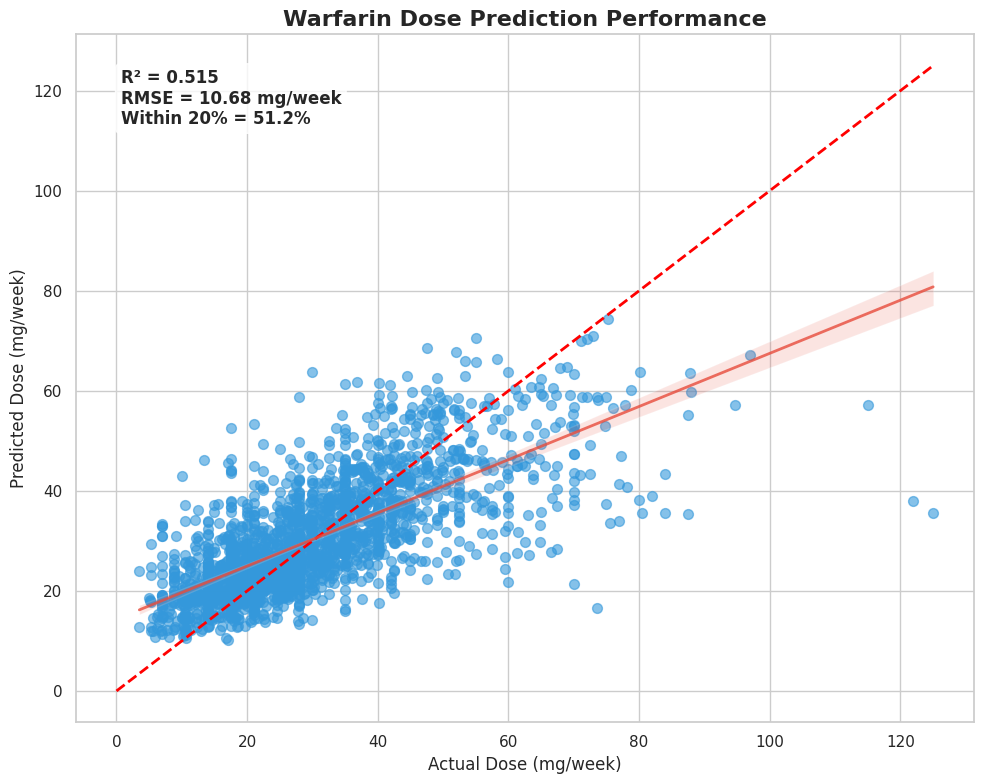

In [45]:
# 5. VISUALIZATION FUNCTIONS (Equivalent Plotting)
def save_fig(fig, filename):
    filepath = os.path.join('output', filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {filepath}")

def create_performance_plot(actual, predicted, metrics):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter plot
    ax.scatter(actual, predicted, alpha=0.6, color="#3498DB", s=50)
    
    # Reference Identity line
    max_val = max(np.max(actual), np.max(predicted))
    ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=2)
    
    # Trend line (approx lm)
    sns.regplot(x=actual, y=predicted, scatter=False, ax=ax, color="#E74C3C", 
                line_kws={'linewidth': 2, 'alpha': 0.8})
    
    # Text Annotation
    text_str = f"R² = {metrics['R2']:.3f}\nRMSE = {metrics['RMSE']:.2f} mg/week\nWithin 20% = {metrics['Within_20pct']:.1f}%"
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title("Warfarin Dose Prediction Performance", fontweight="bold", fontsize=16)
    ax.set_xlabel("Actual Dose (mg/week)")
    ax.set_ylabel("Predicted Dose (mg/week)")
    
    plt.tight_layout()
    return fig

fig1 = create_performance_plot(prep['y_test'], predictions, metrics)
save_fig(fig1, "figure1_performance.png")
plt.show()

Generating SHAP Feature Importance...
✓ Saved: output/figure2_feature_importance.png


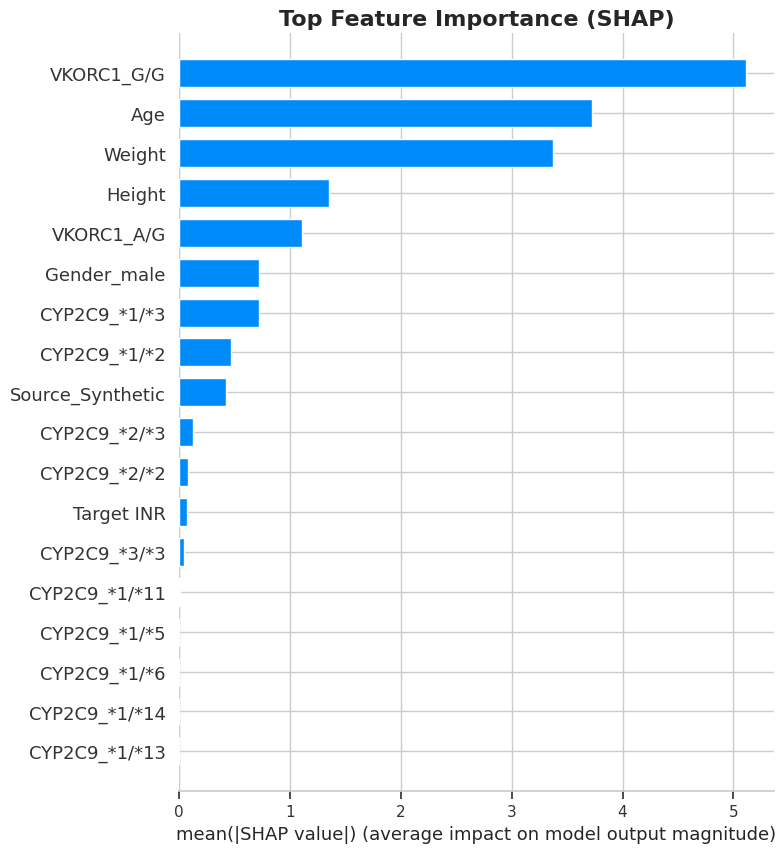

In [46]:
def create_feature_importance_plot(model, feature_names, X_train):
    print("Generating SHAP Feature Importance...")
    fig = plt.figure(figsize=(10, 8))
    
    # SHAP tree explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # Summary plot as bar chart (matches R's gain plot, but better as it shows direction)
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title("Top Feature Importance (SHAP)", fontweight="bold", fontsize=16)
    
    plt.tight_layout()
    return fig

fig2 = create_feature_importance_plot(model, prep['features'], prep['X_train'])
save_fig(fig2, "figure2_feature_importance.png")
plt.show()

✓ Saved: output/figure3_bootstrap.png


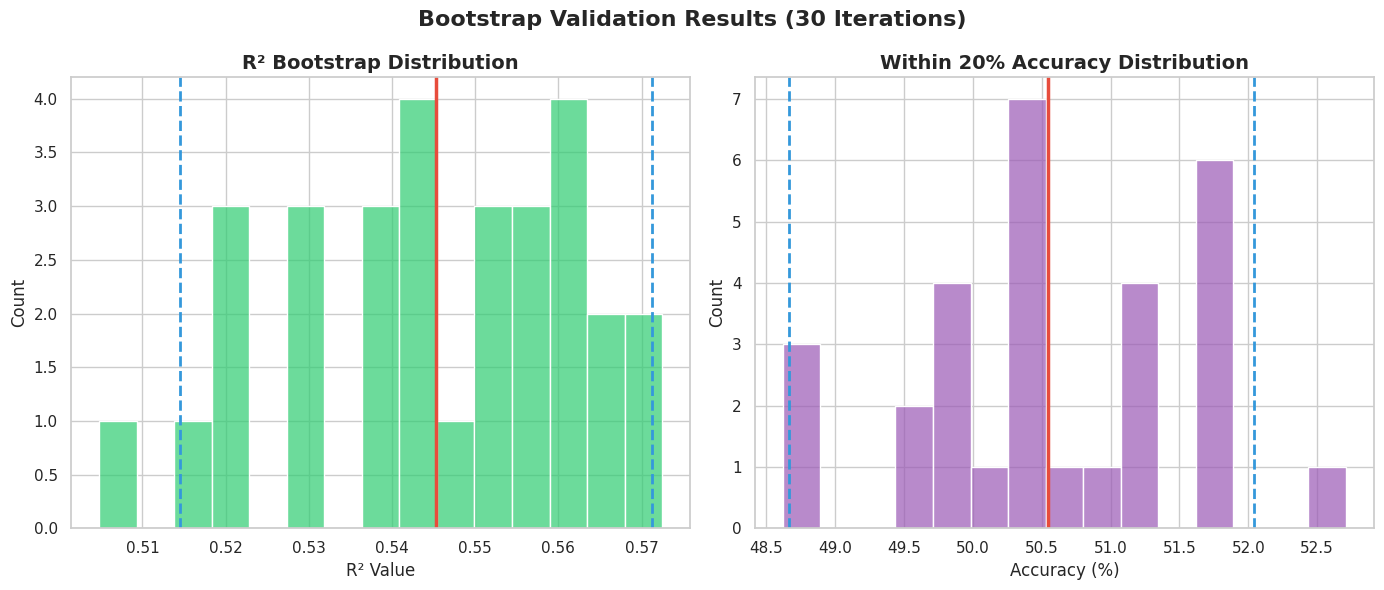

In [47]:
def create_bootstrap_plot(bootstrap_results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # R2 Plot
    sns.histplot(bootstrap_results['results']['R2'], bins=15, ax=axes[0], color="#2ECC71", alpha=0.7)
    axes[0].axvline(bootstrap_results['mean_r2'], color="#E74C3C", linewidth=2.5, label="Mean")
    axes[0].axvline(bootstrap_results['ci_r2'][0], color="#3498DB", linestyle="--", linewidth=2, label="95% CI")
    axes[0].axvline(bootstrap_results['ci_r2'][1], color="#3498DB", linestyle="--", linewidth=2)
    axes[0].set_title("R² Bootstrap Distribution", fontweight="bold", fontsize=14)
    axes[0].set_xlabel("R² Value")
    
    # Within 20% Plot
    sns.histplot(bootstrap_results['results']['Within_20pct'], bins=15, ax=axes[1], color="#9B59B6", alpha=0.7)
    axes[1].axvline(bootstrap_results['mean_within20'], color="#E74C3C", linewidth=2.5, label="Mean")
    axes[1].axvline(bootstrap_results['ci_within20'][0], color="#3498DB", linestyle="--", linewidth=2, label="95% CI")
    axes[1].axvline(bootstrap_results['ci_within20'][1], color="#3498DB", linestyle="--", linewidth=2)
    axes[1].set_title("Within 20% Accuracy Distribution", fontweight="bold", fontsize=14)
    axes[1].set_xlabel("Accuracy (%)")
    
    plt.suptitle("Bootstrap Validation Results (30 Iterations)", fontsize=16, fontweight="bold")
    plt.tight_layout()
    return fig

fig3 = create_bootstrap_plot(boot_res)
save_fig(fig3, "figure3_bootstrap.png")
plt.show()

✓ Saved: output/figure4_residuals.png


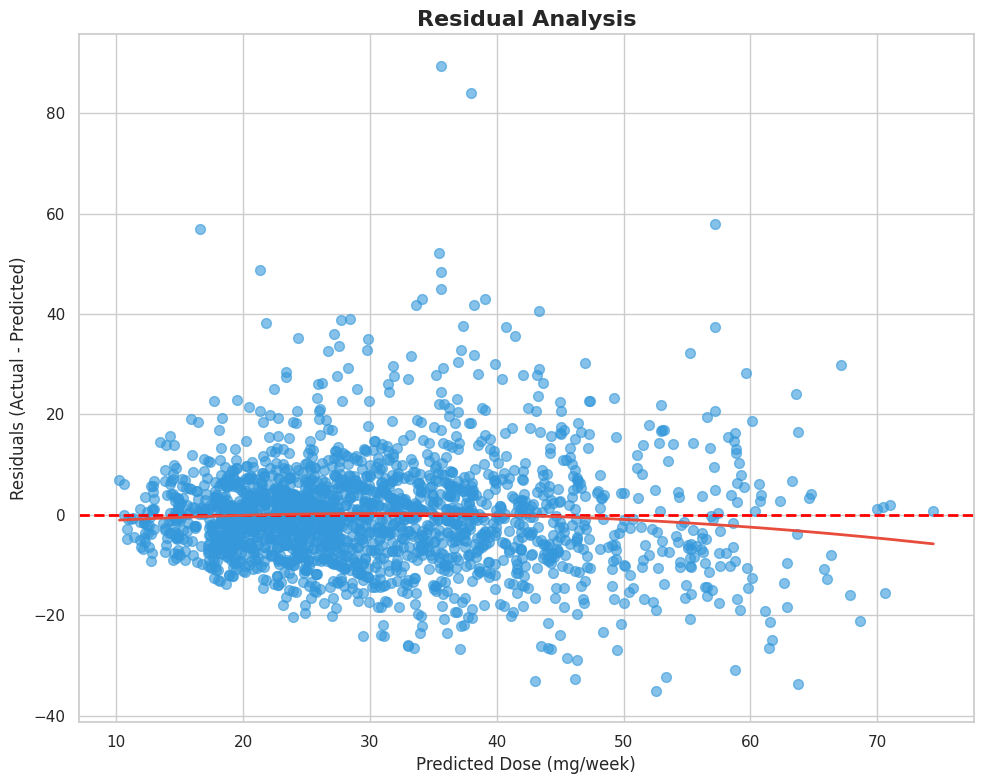

In [48]:
def create_residual_plot(actual, predicted):
    residuals = actual - predicted
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter residuals
    ax.scatter(predicted, residuals, alpha=0.6, color="#3498DB", s=50)
    
    # Zero line
    ax.axhline(0, color="red", linestyle="--", linewidth=2)
    
    # Dependency-free smooth trend (quadratic fit)
    x_vals = np.array(predicted)
    y_vals = np.array(residuals)
    sort_idx = np.argsort(x_vals)
    x_sorted = x_vals[sort_idx]
    y_sorted = y_vals[sort_idx]
    
    poly = np.poly1d(np.polyfit(x_sorted, y_sorted, deg=2))
    ax.plot(x_sorted, poly(x_sorted), color="#E74C3C", linewidth=2)
    
    ax.set_title("Residual Analysis", fontweight="bold", fontsize=16)
    ax.set_xlabel("Predicted Dose (mg/week)")
    ax.set_ylabel("Residuals (Actual - Predicted)")
    
    plt.tight_layout()
    return fig

fig4 = create_residual_plot(prep['y_test'], predictions)
save_fig(fig4, "figure4_residuals.png")
plt.show()

In [49]:
# 6. FINAL RESULTS + EXPORTS (R-script equivalent)
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print("\nPERFORMANCE METRICS:")
print(f"R²: {metrics['R2']:.4f} (95% CI: {boot_res['ci_r2'][0]:.4f} - {boot_res['ci_r2'][1]:.4f})")
print(f"RMSE: {metrics['RMSE']:.2f} mg/week")
print(f"MAE: {metrics['MAE']:.2f} mg/week ({metrics['MAE_percent']:.1f}% of mean dose)")
print(f"Within 10%: {metrics['Within_10pct']:.1f}%")
print(f"Within 20%: {metrics['Within_20pct']:.1f}% (95% CI: {boot_res['ci_within20'][0]:.1f} - {boot_res['ci_within20'][1]:.1f})")
print(f"Within 30%: {metrics['Within_30pct']:.1f}%")

summary_table = pd.DataFrame({
    'Metric': [
        'R²', 'RMSE (mg/week)', 'MAE (mg/week)', 'MAE (% of mean dose)',
        'Within 10%', 'Within 20%', 'Within 30%',
        'Bootstrap R² mean', 'Bootstrap R² CI low', 'Bootstrap R² CI high',
        'Bootstrap Within 20% mean', 'Bootstrap Within 20% CI low', 'Bootstrap Within 20% CI high',
        'Training Samples', 'Test Samples', 'Features'
    ],
    'Value': [
        metrics['R2'], metrics['RMSE'], metrics['MAE'], metrics['MAE_percent'],
        metrics['Within_10pct'], metrics['Within_20pct'], metrics['Within_30pct'],
        boot_res['mean_r2'], boot_res['ci_r2'][0], boot_res['ci_r2'][1],
        boot_res['mean_within20'], boot_res['ci_within20'][0], boot_res['ci_within20'][1],
        prep['X_train'].shape[0], prep['X_test'].shape[0], len(prep['features'])
    ]
})

# Save summary and model
summary_csv_path = os.path.join('output', 'results_summary.csv')
summary_table.to_csv(summary_csv_path, index=False)
model_path = os.path.join('output', 'warfarin_model.xgb')
model.save_model(model_path)

# Save pipeline artifacts for reuse
artifacts_path = os.path.join('output', 'full_results.pkl')
pd.to_pickle({
    'metrics': metrics,
    'bootstrap': boot_res,
    'features': prep['features'],
    'train_shape': prep['X_train'].shape,
    'test_shape': prep['X_test'].shape
}, artifacts_path)

print("\nSAVED OUTPUTS:")
print("- output/figure1_performance.png")
print("- output/figure2_feature_importance.png")
print("- output/figure3_bootstrap.png")
print("- output/figure4_residuals.png")
print("- output/results_summary.csv")
print("- output/warfarin_model.xgb")
print("- output/full_results.pkl")

FINAL RESULTS

PERFORMANCE METRICS:
R²: 0.5152 (95% CI: 0.5145 - 0.5713)
RMSE: 10.68 mg/week
MAE: 7.54 mg/week (24.8% of mean dose)
Within 10%: 27.7%
Within 20%: 51.2% (95% CI: 48.7 - 52.0)
Within 30%: 67.6%

SAVED OUTPUTS:
- output/figure1_performance.png
- output/figure2_feature_importance.png
- output/figure3_bootstrap.png
- output/figure4_residuals.png
- output/results_summary.csv
- output/warfarin_model.xgb
- output/full_results.pkl
